# Data Evaluation: Solvability (User Study Task 1)

## 0. Setup

In [25]:
import pandas as pd
import matplotlib as mpl
from scipy.stats import wilcoxon, mannwhitneyu, kruskal
from sklearn.metrics import mutual_info_score
import numpy as np
np.set_printoptions(legacy='1.25')
%matplotlib inline

data_df = pd.read_csv('../ma-eval/combined-data.csv')
data_df

,participant,p_id,date,group,s_iss_miro,s_tp_miro,s_fp_miro,s_iss_pixie,s_tp_pixie,s_fp_pixie,...,UEQS-4,UEQS-5,UEQS-6,UEQS-7,UEQS-8,C-Q1,C-Q2,C-Q3,C-Q4,FQ2
0,1,MA12534,2026-06-29,AM,3,2,1,0,0,0,...,3,6,7,7,7,3,1,2,4,NaN
1,21,MA26593,2026-07-07,AM,1,1,0,0,0,0,...,3,5,6,7,6,3,4,4,4,NaN
2,13,MA34230,2026-07-01,AM,3,3,0,1,1,0,...,6,6,6,7,7,2,4,4,5,The locks need to be differentiable by look
3,5,MA7125,2026-06-30,AM,4,1,3,2,2,0,...,6,5,7,5,5,5,4,5,5,NaN
4,17,MA95137,2026-07-02,AM,2,2,0,0,0,0,...,2,7,7,6,5,5,4,4,5,It's nice to use but it takes some time to get...
5,9,MA95935,2026-06-30,AM,2,1,1,0,0,0,...,7,7,7,4,4,5,5,5,5,"Would have liked to have a ""total time needed ..."
6,15,MB10509,2026-07-02,BM,2,2,0,1,1,1,...,7,7,7,5,5,3,5,5,4,Tool did not make it clear which locks had whi...
7,7,MB24145,2026-06-30,BM,3,3,0,2,1,1,...,3,6,6,4,5,4,4,4,4,Please for gods sake put more contrast between...
8,23,MB41880,2026-07-07,BM,1,1,0,0,0,0,...,4,3,5,2,2,2,1,4,3,I feel like so much potential is wasted not in...
9,11,MB50964,2026-07-01,BM,2,2,0,4,2,2,...,5,7,7,6,6,4,4,4,5,i wasn't really sure what happened in the path...


In [26]:
data_df['first_tool'] = 'Default'
data_df['first_tool'] = data_df['first_tool'].case_when(
    [
        (data_df['group'] == 'AM', 'Miro'),
        (data_df['group'] == 'AP', 'pixie'),
        (data_df['group'] == 'BM', 'Miro'),
        (data_df['group'] == 'BP', 'pixie'),
    ]
)

In [27]:
data_df['first_task'] = 'Default'
data_df['first_task'] = data_df['first_task'].case_when(
    [
        (data_df['group'] == 'AM', 'A'),
        (data_df['group'] == 'AP', 'A'),
        (data_df['group'] == 'BM', 'B'),
        (data_df['group'] == 'BP', 'B'),
    ]
)

## 1. Counts of Identified Issues

In [28]:
total_counts_solvability = [
    's_iss_miro',
    's_iss_pixie',
]

#### Distribution of Total Number of Identified Issues Across Participants By Tool

includes incorrect answers

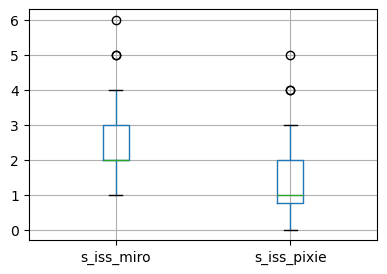

In [29]:
total_solvability_boxplot = data_df.boxplot(column=total_counts_solvability, figsize=(4.5, 3))

In [30]:
wilc_total_issues = wilcoxon(data_df['s_iss_miro'], data_df['s_iss_pixie'])
wilc_total_issues.statistic, wilc_total_issues.pvalue

(48.5, 0.00564929988211376)

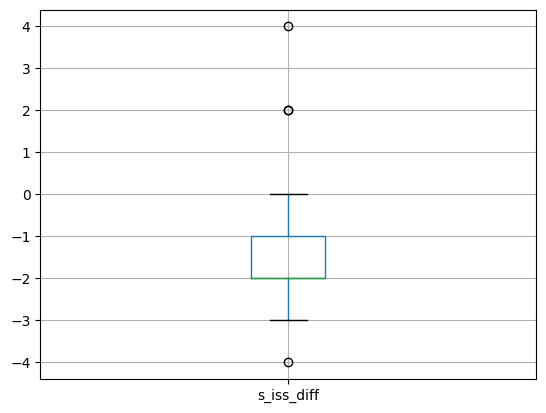

In [31]:
data_df['s_iss_diff'] = data_df['s_iss_pixie'] - data_df['s_iss_miro']
solvability_diff = data_df.boxplot(column=['s_iss_diff'])

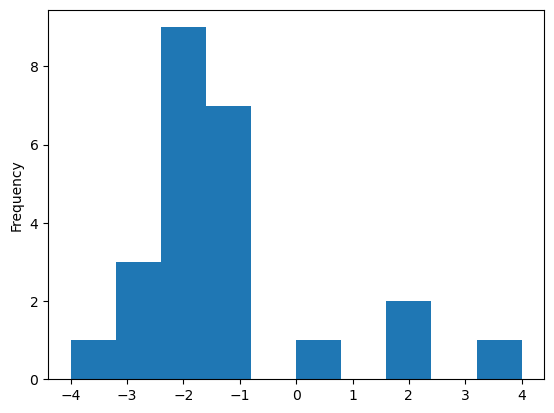

In [32]:
solvability_diff_hist = data_df['s_iss_diff'].plot.hist()

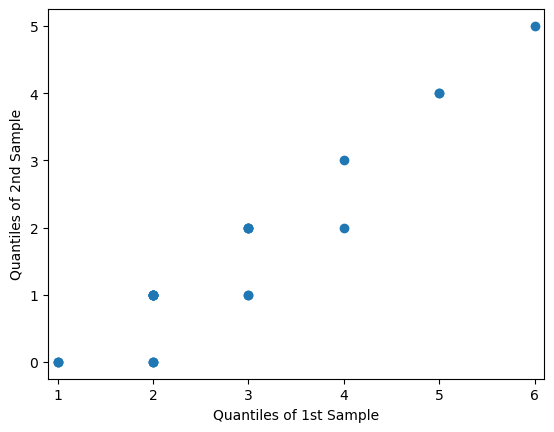

In [33]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
from statsmodels.graphics.gofplots import qqplot_2samples

qqplot_2samples(data_df['s_iss_miro'], data_df['s_iss_pixie'])
plt.show()

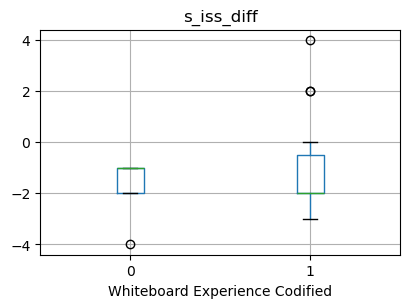

In [34]:
solvability_diff_by_wb_exp = data_df.boxplot(column=['s_iss_diff'], by="Whiteboard Experience Codified", figsize=(4.5, 3))
# solvability_diff_by_wb_exp.set_title('')
fig = solvability_diff_by_wb_exp.get_figure()
fig._suptitle.set_visible(False)
fig._suptitle.set_in_layout(False)

In [35]:
data_exp_yes = data_df.loc[data_df['Whiteboard Experience Codified'] == 1]
data_exp_no = data_df.loc[data_df['Whiteboard Experience Codified'] == 0]

mwu_total_issues_wb_exp = mannwhitneyu(data_exp_yes['s_iss_diff'], data_exp_no['s_iss_diff'])
mwu_total_issues_wb_exp.statistic, mwu_total_issues_wb_exp.pvalue

(67.0, 1.0)

#### By Tool And Group

Text(0.5, 0.98, '')

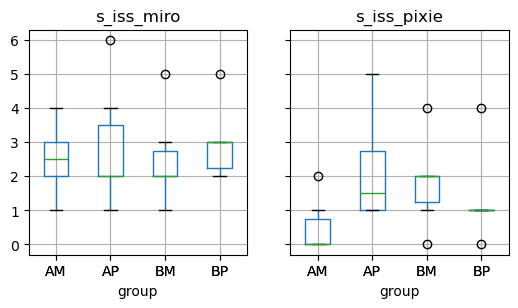

In [36]:
total_solvability_by_group_boxplot = data_df.boxplot(column=total_counts_solvability, by='group', figsize=(6, 3))
plt.suptitle('')

In [37]:
data_df_am = data_df[data_df['group'] == 'AM']
data_df_ap = data_df[data_df['group'] == 'AP']
data_df_bm = data_df[data_df['group'] == 'BM']
data_df_bp = data_df[data_df['group'] == 'BP']

In [38]:
kruskal_iss_groups_miro = kruskal(
    data_df_am['s_iss_miro'],
    data_df_ap['s_iss_miro'],
    data_df_bm['s_iss_miro'],
    data_df_bp['s_iss_miro'],
)
kruskal_iss_groups_miro.statistic, kruskal_iss_groups_miro.pvalue

(1.0379656160458535, 0.792066472134847)

In [39]:
(kruskal_iss_groups_miro.statistic - 6 + 1)/(24 - 6)

-0.22011302133078592

In [40]:
kruskal_iss_groups_pixie = kruskal(
    data_df_am['s_iss_pixie'],
    data_df_ap['s_iss_pixie'],
    data_df_bm['s_iss_pixie'],
    data_df_bp['s_iss_pixie'],
)
kruskal_iss_groups_pixie.statistic, kruskal_iss_groups_pixie.pvalue

(6.302259887005658, 0.09779572832771925)

In [41]:
(kruskal_iss_groups_pixie.statistic - 6 + 1)/(24 - 6)

0.07234777150031431

#### By Tool and Whiteboard Experience

Text(0.5, 0.98, '')

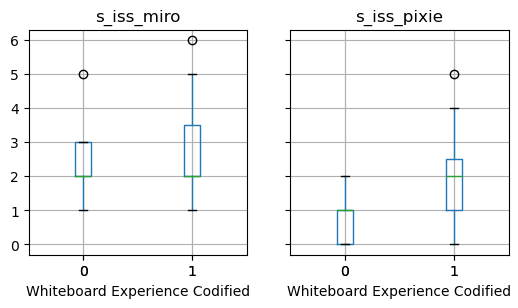

In [42]:
total_solvability_by_wb_exp = data_df.boxplot(column=total_counts_solvability, by='Whiteboard Experience Codified', figsize=(6,3))
plt.suptitle('')

*x*: issues in pixie *with* whiteboard experience
*y*: issues in pixie *without* whiteboard experience

$H_0$: the distribution underlying x is not stochastically greater than (i.e. is smaller than or equal to) the distribution underlying y

$H_{alt}$: the distribution underlying x is stochastically greater than the distribution underlying y, i.e. SX(u) > SY(u) for all u

In [43]:
mwu_pixie_issues_wb_exp = mannwhitneyu(data_exp_yes['s_iss_pixie'], data_exp_no['s_iss_pixie'], alternative='greater')
mwu_pixie_issues_wb_exp.statistic, mwu_pixie_issues_wb_exp.pvalue

(96.5, 0.03849541272254616)

In [44]:
data_exp_yes['s_iss_pixie'].describe()

count    15.000000
mean      1.866667
std       1.552264
min       0.000000
25%       1.000000
50%       2.000000
75%       2.500000
max       5.000000
Name: s_iss_pixie, dtype: float64

### By Tool and Miro Usage

Text(0.5, 0.98, '')

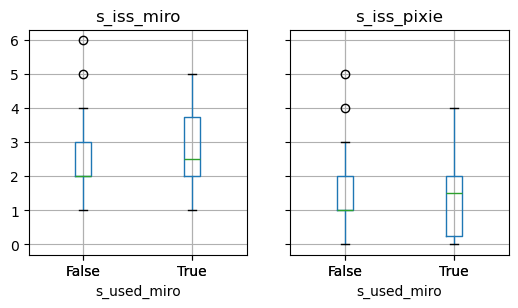

In [45]:
total_solvability_boxplot_by_miro_usage = data_df.boxplot(column=total_counts_solvability, by='s_used_miro', figsize=(6, 3))
plt.suptitle('')

In [46]:
data_df[['Whiteboard Experience Codified', 's_used_miro']].corr()

,Whiteboard Experience Codified,s_used_miro
Whiteboard Experience Codified,1.000000,0.248452
s_used_miro,0.248452,1.000000


In [47]:
mutual_info_score(data_df['Whiteboard Experience Codified'], data_df['s_used_miro'])

0.03370175349341352

*x*: total issues in Miro *with* Miro usage

*y*: total issues in Miro *without* Miro usage

$H_0$: the distribution underlying x is not stochastically greater than (i.e. is smaller than or equal to) the distribution underlying y

$H_{alt}$: the distribution underlying x is stochastically greater than the distribution underlying y, i.e. SX(u) > SY(u) for all u

In [48]:
data_usage_yes = data_df.loc[data_df['s_used_miro'] == 1]
data_usage_no = data_df.loc[data_df['s_used_miro'] == 0]

In [49]:
mwu_miro_iss_wb_usg = mannwhitneyu(data_usage_yes['s_iss_miro'], data_usage_no['s_iss_miro'], alternative='greater')
mwu_miro_iss_wb_usg.statistic, mwu_miro_iss_wb_usg.pvalue

(57.5, 0.4169872469244896)

In [50]:
data_usage_yes['s_iss_miro'].median()

2.5

In [51]:
data_usage_no['s_iss_miro'].median()

2.0

### Total Issues By First Tool

Text(0.5, 0.98, '')

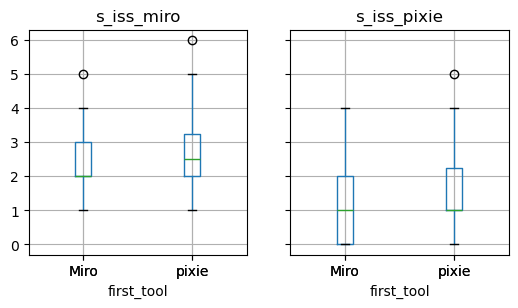

In [52]:
solvability_iss_by_first_tool = data_df.boxplot(column=['s_iss_miro', 's_iss_pixie'], by='first_tool', figsize=(6, 3))
plt.suptitle('')

In [53]:
data_miro_first = data_df.loc[data_df['first_tool'] == 'Miro']
data_pixie_first = data_df.loc[data_df['first_tool'] == 'pixie']

In [54]:
mwu_pixie_iss_first_tool = mannwhitneyu(data_miro_first['s_iss_pixie'], data_pixie_first['s_iss_pixie'], alternative='less')
mwu_pixie_iss_first_tool.statistic, mwu_pixie_iss_first_tool.pvalue

(56.0, 0.17586687210000918)

In [55]:
mwu_miro_iss_first_tool = mannwhitneyu(data_miro_first['s_iss_miro'], data_pixie_first['s_iss_miro'], alternative='two-sided')
mwu_miro_iss_first_tool.statistic, mwu_miro_iss_first_tool.pvalue

(61.0, 0.5252085487808955)

In [56]:
mwu_iss_miro_first = mannwhitneyu(data_miro_first['s_iss_miro'], data_miro_first['s_iss_pixie'], alternative='greater')
mwu_iss_miro_first.statistic, mwu_iss_miro_first.pvalue

(113.5, 0.007119626847890099)

In [57]:
mwu_iss_pixie_first = mannwhitneyu(data_pixie_first['s_iss_miro'], data_pixie_first['s_iss_pixie'], alternative='greater')
mwu_iss_pixie_first.statistic, mwu_iss_pixie_first.pvalue

(109.5, 0.013911974800880097)

### Total Issues By First Task Version

Text(0.5, 0.98, '')

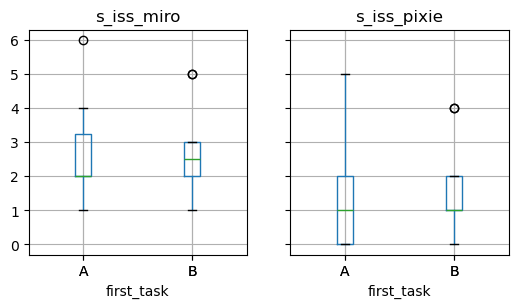

In [58]:
solvability_iss_by_first_task = data_df.boxplot(column=['s_iss_miro', 's_iss_pixie'], by='first_task', figsize=(6, 3))
plt.suptitle('')

In [59]:
data_a_first = data_df.loc[data_df['first_task'] == 'A']
data_b_first = data_df.loc[data_df['first_task'] == 'B']

In [60]:
mwu_pixie_iss_first_task = mannwhitneyu(data_a_first['s_iss_pixie'], data_b_first['s_iss_pixie'], alternative='less')
mwu_pixie_iss_first_task.statistic, mwu_pixie_iss_first_task.pvalue

(61.0, 0.2640744204027525)

In [61]:
mwu_miro_iss_first_task = mannwhitneyu(data_a_first['s_iss_miro'], data_b_first['s_iss_miro'], alternative='two-sided')
mwu_miro_iss_first_task.statistic, mwu_miro_iss_first_task.pvalue

(66.5, 0.7622393020208187)

In [62]:
mwu_iss_a_first = mannwhitneyu(data_a_first['s_iss_miro'], data_a_first['s_iss_pixie'], alternative='greater')
mwu_iss_a_first.statistic, mwu_iss_a_first.pvalue

(112.0, 0.009772385914774426)

In [63]:
mwu_iss_b_first = mannwhitneyu(data_b_first['s_iss_miro'], data_b_first['s_iss_pixie'], alternative='greater')
mwu_iss_b_first.statistic, mwu_iss_b_first.pvalue

(111.0, 0.011026117625531191)

### Precision

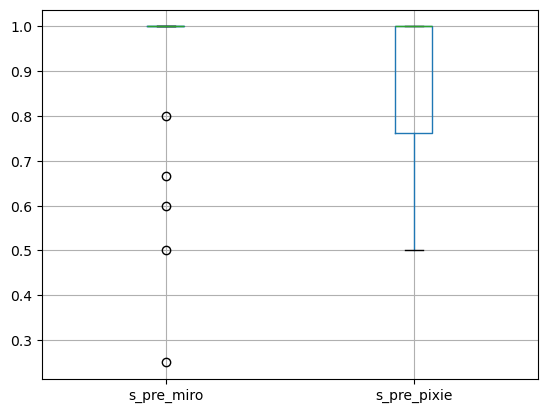

In [64]:
TOTAL_ISSUES = 6

data_df['s_pre_miro'] = data_df['s_tp_miro'] / data_df['s_iss_miro']
data_df['s_pre_pixie'] = data_df['s_tp_pixie'] / data_df['s_iss_pixie']

solvability_precision_boxplot = data_df.boxplot(column=['s_pre_miro', 's_pre_pixie'])

In [65]:
# NOTE: missing values for precision when 0 issues identified
data_df[['s_pre_miro', 's_pre_pixie']].describe()

,s_pre_miro,s_pre_pixie
count,24.000000,18.000000
mean,0.909028,0.873148
std,0.200541,0.199111
min,0.250000,0.500000
25%,1.000000,0.762500
50%,1.000000,1.000000
75%,1.000000,1.000000
max,1.000000,1.000000


### Recall

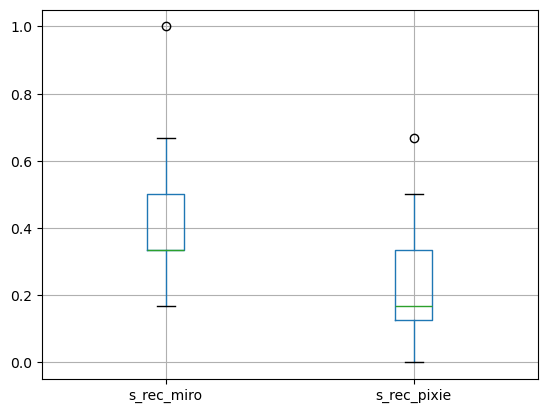

In [66]:
data_df['s_rec_miro'] = data_df['s_tp_miro'] / TOTAL_ISSUES
data_df['s_rec_pixie'] = data_df['s_tp_pixie'] / TOTAL_ISSUES

solvability_recall_boxplot = data_df.boxplot(column=['s_rec_miro', 's_rec_pixie'])

In [67]:
data_df[['s_rec_miro', 's_rec_pixie']].describe()

,s_rec_miro,s_rec_pixie
count,24.000000,24.000000
mean,0.395833,0.194444
std,0.195434,0.167870
min,0.166667,0.000000
25%,0.333333,0.125000
50%,0.333333,0.166667
75%,0.500000,0.333333
max,1.000000,0.666667


### F1

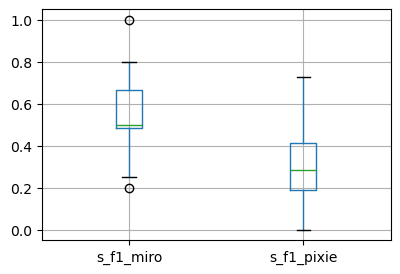

In [68]:
data_df['s_f1_miro'] = 2 * data_df['s_tp_miro'] / (2 * data_df['s_tp_miro'] + data_df['s_fp_miro'] + (TOTAL_ISSUES - data_df['s_tp_miro']))
data_df['s_f1_pixie'] = 2 * data_df['s_tp_pixie'] / (2 * data_df['s_tp_pixie'] + data_df['s_fp_pixie'] + (TOTAL_ISSUES - data_df['s_tp_pixie']))
solvability_f1_boxplot = data_df.boxplot(column=['s_f1_miro', 's_f1_pixie'], figsize=(4.5, 3))

In [69]:
wilc_f1_issues = wilcoxon(data_df['s_f1_miro'], data_df['s_f1_pixie'])
wilc_f1_issues.statistic, wilc_f1_issues.pvalue

(34.0, 0.0009066055498154164)

In [70]:
data_df[['s_f1_miro', 's_f1_pixie']].describe()

# TODO: investigate missing value

,s_f1_miro,s_f1_pixie
count,24.000000,24.000000
mean,0.525508,0.277161
std,0.187462,0.202259
min,0.200000,0.000000
25%,0.486111,0.187500
50%,0.500000,0.285714
75%,0.666667,0.411111
max,1.000000,0.727273


#### F1 Difference Per Participant

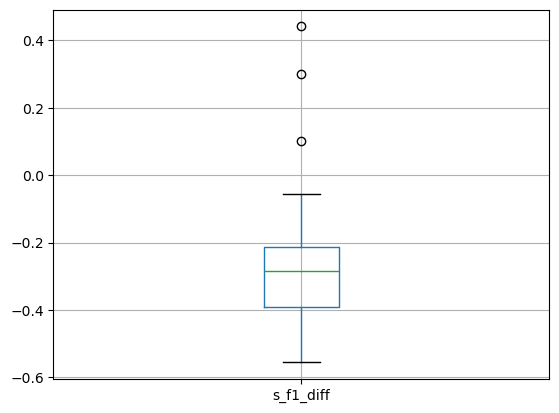

In [71]:
data_df['s_f1_diff'] = data_df['s_f1_pixie'] - data_df['s_f1_miro']
solvability_f1_diff = data_df.boxplot(column=['s_f1_diff'])

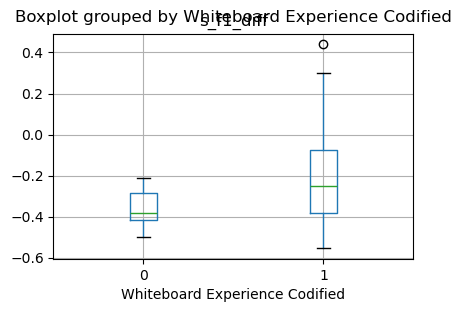

In [72]:
solvability_f1_diff_by_wb_exp = data_df.boxplot(column=['s_f1_diff'], by='Whiteboard Experience Codified', figsize=(4.5, 3))

In [73]:
data_df['s_f1_diff'].describe()

count    24.000000
mean     -0.248347
std       0.243312
min      -0.555556
25%      -0.389881
50%      -0.285714
75%      -0.214286
max       0.441558
Name: s_f1_diff, dtype: float64

#### F1 Stratified By Group

Text(0.5, 0.98, '')

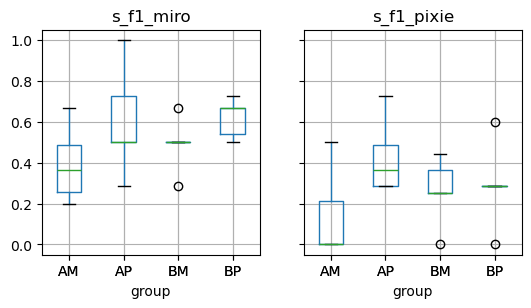

In [74]:
solvability_f1_by_group_boxplot = data_df.boxplot(column=['s_f1_miro', 's_f1_pixie'], by='group', figsize=(6, 3))
plt.suptitle('')

In [75]:
data_df_am = data_df[data_df['group'] == 'AM']
data_df_ap = data_df[data_df['group'] == 'AP']
data_df_bm = data_df[data_df['group'] == 'BM']
data_df_bp = data_df[data_df['group'] == 'BP']

In [76]:
data_df_am

,participant,p_id,date,group,s_iss_miro,s_tp_miro,s_fp_miro,s_iss_pixie,s_tp_pixie,s_fp_pixie,...,first_tool,first_task,s_iss_diff,s_pre_miro,s_pre_pixie,s_rec_miro,s_rec_pixie,s_f1_miro,s_f1_pixie,s_f1_diff
0,1,MA12534,2026-06-29,AM,3,2,1,0,0,0,...,Miro,A,-3,0.666667,NaN,0.333333,0.000000,0.444444,0.000000,-0.444444
1,21,MA26593,2026-07-07,AM,1,1,0,0,0,0,...,Miro,A,-1,1.000000,NaN,0.166667,0.000000,0.285714,0.000000,-0.285714
2,13,MA34230,2026-07-01,AM,3,3,0,1,1,0,...,Miro,A,-2,1.000000,1.0,0.500000,0.166667,0.666667,0.285714,-0.380952
3,5,MA7125,2026-06-30,AM,4,1,3,2,2,0,...,Miro,A,-2,0.250000,1.0,0.166667,0.333333,0.200000,0.500000,0.300000
4,17,MA95137,2026-07-02,AM,2,2,0,0,0,0,...,Miro,A,-2,1.000000,NaN,0.333333,0.000000,0.500000,0.000000,-0.500000
5,9,MA95935,2026-06-30,AM,2,1,1,0,0,0,...,Miro,A,-2,0.500000,NaN,0.166667,0.000000,0.250000,0.000000,-0.250000


Miro:

In [77]:
kruskal_f1_groups_miro = kruskal(
    data_df_am['s_f1_miro'],
    data_df_ap['s_f1_miro'],
    data_df_bm['s_f1_miro'],
    data_df_bp['s_f1_miro'],
)
kruskal_f1_groups_miro.statistic, kruskal_f1_groups_miro.pvalue

(6.782330648981534, 0.07916893329942976)

In [78]:
(kruskal_f1_groups_miro.statistic - 6 + 1)/(24 - 6)

0.09901836938786301

pix:e:

In [79]:
kruskal_f1_groups_pixie = kruskal(
    data_df_am['s_f1_pixie'],
    data_df_ap['s_f1_pixie'],
    data_df_bm['s_f1_pixie'],
    data_df_bp['s_f1_pixie'],
)
kruskal_f1_groups_pixie.statistic, kruskal_f1_groups_pixie.pvalue

(6.1209961685823835, 0.10586961600347922)

In [80]:
(kruskal_f1_groups_pixie.statistic - 6 + 1)/(24 - 6)

0.062277564921243526

#### F1 Stratified By First Tool

Text(0.5, 0.98, '')

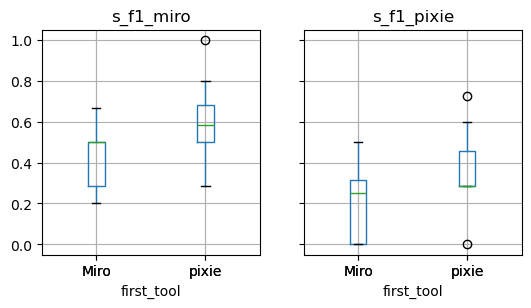

In [81]:
solvability_f1_by_first_tool = data_df.boxplot(column=['s_f1_miro', 's_f1_pixie'], by='first_tool', figsize=(6, 3))
plt.suptitle('')

In [82]:
data_miro_first = data_df.loc[data_df['first_tool'] == 'Miro']
data_pixie_first = data_df.loc[data_df['first_tool'] == 'pixie']

In [83]:
mwu_pixie_f1_first_tool = mannwhitneyu(data_miro_first['s_f1_pixie'], data_pixie_first['s_f1_pixie'], alternative='less')
mwu_pixie_f1_first_tool.statistic, mwu_pixie_f1_first_tool.pvalue

(36.0, 0.01752989821262875)

In [84]:
mwu_miro_f1_first_tool = mannwhitneyu(data_miro_first['s_f1_miro'], data_pixie_first['s_f1_miro'], alternative='less')
mwu_miro_f1_first_tool.statistic, mwu_miro_f1_first_tool.pvalue

(34.5, 0.012881216468546798)

In [85]:
mwu_f1_miro_first = mannwhitneyu(data_miro_first['s_f1_miro'], data_miro_first['s_f1_pixie'], alternative='greater')
mwu_f1_miro_first.statistic, mwu_f1_miro_first.pvalue

(120.5, 0.002438315994973508)

In [86]:
mwu_f1_pixie_first = mannwhitneyu(data_pixie_first['s_f1_miro'], data_pixie_first['s_f1_pixie'], alternative='greater')
mwu_f1_pixie_first.statistic, mwu_f1_pixie_first.pvalue

(120.5, 0.0021918208622532997)

#### F1 Stratified By First Task Version

Text(0.5, 0.98, '')

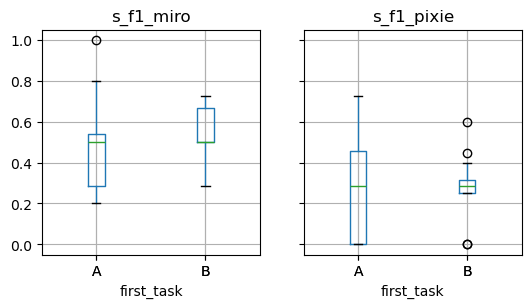

In [87]:
solvability_f1_by_first_task = data_df.boxplot(column=['s_f1_miro', 's_f1_pixie'], by='first_task', figsize=(6, 3))
plt.suptitle('')

In [88]:
data_a_first = data_df.loc[data_df['first_task'] == 'A']
data_b_first = data_df.loc[data_df['first_task'] == 'B']

mwu_pixie_f1_first_task = mannwhitneyu(data_a_first['s_f1_pixie'], data_b_first['s_f1_pixie'], alternative='two-sided')
mwu_pixie_f1_first_task.statistic, mwu_pixie_f1_first_task.pvalue

(76.5, 0.8122816289421281)

In [ ]:
mwu_miro_f1_first_task = mannwhitneyu(data_a_first['s_f1_miro'], data_b_first['s_f1_miro'], alternative='two-sided')
mwu_miro_f1_first_task.statistic, mwu_miro_f1_first_task.pvalue

(51.0, 0.1083379592556471)

In [90]:
mwu_f1_a_first = mannwhitneyu(data_a_first['s_f1_miro'], data_a_first['s_f1_pixie'], alternative='greater')
mwu_f1_a_first.statistic, mwu_f1_a_first.pvalue

(103.5, 0.03421541178220448)

In [91]:
mwu_f1_b_first = mannwhitneyu(data_b_first['s_f1_miro'], data_b_first['s_f1_pixie'], alternative='greater')
mwu_f1_b_first.statistic, mwu_f1_b_first.pvalue

(133.0, 0.00019455040089827797)

#### F1 Stratified By Whiteboard Experience

Text(0.5, 0.98, '')

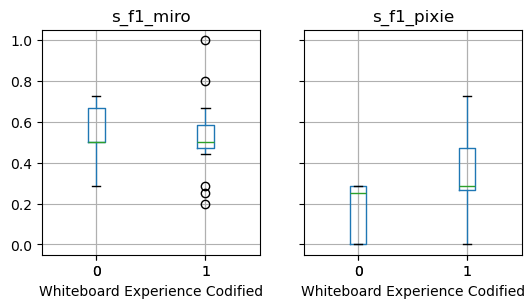

In [92]:
solvability_f1_by_whiteboard_exp_boxplot = data_df.boxplot(column=['s_f1_miro', 's_f1_pixie'], by='Whiteboard Experience Codified', figsize=(6, 3))
plt.suptitle('')

In [93]:
wilc_f1_wb_exp = wilcoxon(
    data_df[data_df['Whiteboard Experience Codified'] == 1]['s_f1_miro'], 
    data_df[data_df['Whiteboard Experience Codified'] == 1]['s_f1_pixie'],
    alternative='greater'
)
wilc_f1_wb_exp.statistic, wilc_f1_wb_exp.pvalue

(97.5, 0.016520835153317044)

*x*: f1 in pixie *with* whiteboard experience

*y*: f1 in pixie *without* whiteboard experience

$H_0$: the distribution underlying x is not stochastically greater than (i.e. is smaller than or equal to) the distribution underlying y

$H_{alt}$: the distribution underlying x is stochastically greater than the distribution underlying y, i.e. SX(u) > SY(u) for all u

In [94]:
data_exp_yes = data_df.loc[data_df['Whiteboard Experience Codified'] == 1]
data_exp_no = data_df.loc[data_df['Whiteboard Experience Codified'] == 0]

mwu_pixie_f1_wb_exp = mannwhitneyu(data_exp_yes['s_f1_pixie'], data_exp_no['s_f1_pixie'], alternative='greater')
mwu_pixie_f1_wb_exp.statistic, mwu_pixie_f1_wb_exp.pvalue


(99.5, 0.026709563347505107)

In [95]:
data_exp_yes['s_f1_pixie'].describe()

count    15.000000
mean      0.333935
std       0.217179
min       0.000000
25%       0.267857
50%       0.285714
75%       0.472222
max       0.727273
Name: s_f1_pixie, dtype: float64

In [96]:
data_exp_no['s_f1_pixie'].describe()

count    9.000000
mean     0.182540
std      0.137679
min      0.000000
25%      0.000000
50%      0.250000
75%      0.285714
max      0.285714
Name: s_f1_pixie, dtype: float64

#### F1 By Miro Usage

Text(0.5, 0.98, '')

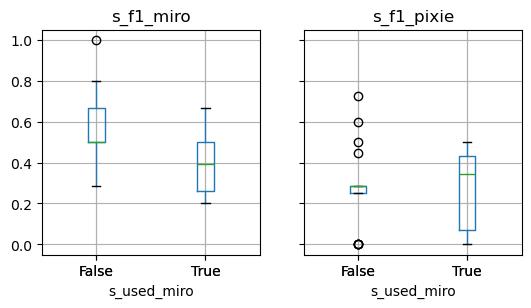

In [97]:
solvability_f1_by_miro_usage = data_df.boxplot(column=['s_f1_miro', 's_f1_pixie'], by='s_used_miro', figsize=(6, 3))
plt.suptitle('')

*x*: F1 in Miro *with* Miro usage

*y*: F1 in Miro *without* Miro usage

$H_0$: the distribution underlying x is not stochastically greater than (i.e. is smaller than or equal to) the distribution underlying y

$H_{alt}$: the distribution underlying x is stochastically greater than the distribution underlying y, i.e. SX(u) > SY(u) for all u

In [98]:
data_usage_yes = data_df.loc[data_df['s_used_miro'] == 1]
data_usage_no = data_df.loc[data_df['s_used_miro'] == 0]

In [99]:
mwu_miro_f1_wb_usg = mannwhitneyu(data_usage_yes['s_f1_miro'], data_usage_no['s_f1_miro'], alternative='two-sided')
mwu_miro_iss_wb_usg.statistic, mwu_miro_iss_wb_usg.pvalue

(57.5, 0.4169872469244896)

In [100]:
data_usage_yes['s_f1_miro'].median()

0.39285714285714285

In [101]:
data_usage_no['s_f1_miro'].median()

0.5

## Comparison Between Tasks

In [102]:
data_df['s_f1_a'] = 'Default'
data_df['s_f1_a'] = data_df['s_f1_a'].case_when(
    [
        (data_df['group'] == 'AM', data_df['s_f1_miro']),
        (data_df['group'] == 'AP', data_df['s_f1_pixie']),
        (data_df['group'] == 'BM', data_df['s_f1_pixie']),
        (data_df['group'] == 'BP', data_df['s_f1_miro']),
    ]
)

data_df['s_f1_b'] = 'Default'
data_df['s_f1_b'] = data_df['s_f1_b'].case_when(
    [
        (data_df['group'] == 'AM', data_df['s_f1_pixie']),
        (data_df['group'] == 'AP', data_df['s_f1_miro']),
        (data_df['group'] == 'BM', data_df['s_f1_miro']),
        (data_df['group'] == 'BP', data_df['s_f1_pixie']),
    ]
)

data_df['s_iss_a'] = 'Default'
data_df['s_iss_a'] = data_df['s_iss_a'].case_when(
    [
        (data_df['group'] == 'AM', data_df['s_iss_miro']),
        (data_df['group'] == 'AP', data_df['s_iss_pixie']),
        (data_df['group'] == 'BM', data_df['s_iss_pixie']),
        (data_df['group'] == 'BP', data_df['s_iss_miro']),
    ]
)

data_df['s_iss_b'] = 'Default'
data_df['s_iss_b'] = data_df['s_iss_b'].case_when(
    [
        (data_df['group'] == 'AM', data_df['s_iss_pixie']),
        (data_df['group'] == 'AP', data_df['s_iss_miro']),
        (data_df['group'] == 'BM', data_df['s_iss_miro']),
        (data_df['group'] == 'BP', data_df['s_iss_pixie']),
    ]
)
data_df[['s_f1_a', 's_f1_b', 's_iss_a', 's_iss_b']] = data_df[['s_f1_a', 's_f1_b', 's_iss_a', 's_iss_b']].apply(pd.to_numeric)
data_df

,participant,p_id,date,group,s_iss_miro,s_tp_miro,s_fp_miro,s_iss_pixie,s_tp_pixie,s_fp_pixie,...,s_pre_pixie,s_rec_miro,s_rec_pixie,s_f1_miro,s_f1_pixie,s_f1_diff,s_f1_a,s_f1_b,s_iss_a,s_iss_b
0,1,MA12534,2026-06-29,AM,3,2,1,0,0,0,...,NaN,0.333333,0.000000,0.444444,0.000000,-0.444444,0.444444,0.000000,3,0
1,21,MA26593,2026-07-07,AM,1,1,0,0,0,0,...,NaN,0.166667,0.000000,0.285714,0.000000,-0.285714,0.285714,0.000000,1,0
2,13,MA34230,2026-07-01,AM,3,3,0,1,1,0,...,1.000000,0.500000,0.166667,0.666667,0.285714,-0.380952,0.666667,0.285714,3,1
3,5,MA7125,2026-06-30,AM,4,1,3,2,2,0,...,1.000000,0.166667,0.333333,0.200000,0.500000,0.300000,0.200000,0.500000,4,2
4,17,MA95137,2026-07-02,AM,2,2,0,0,0,0,...,NaN,0.333333,0.000000,0.500000,0.000000,-0.500000,0.500000,0.000000,2,0
5,9,MA95935,2026-06-30,AM,2,1,1,0,0,0,...,NaN,0.166667,0.000000,0.250000,0.000000,-0.250000,0.250000,0.000000,2,0
6,15,MB10509,2026-07-02,BM,2,2,0,1,1,1,...,1.000000,0.333333,0.166667,0.500000,0.250000,-0.250000,0.250000,0.500000,1,2
7,7,MB24145,2026-06-30,BM,3,3,0,2,1,1,...,0.500000,0.500000,0.166667,0.666667,0.250000,-0.416667,0.250000,0.666667,2,3
8,23,MB41880,2026-07-07,BM,1,1,0,0,0,0,...,NaN,0.166667,0.000000,0.285714,0.000000,-0.285714,0.000000,0.285714,0,1
9,11,MB50964,2026-07-01,BM,2,2,0,4,2,2,...,0.500000,0.333333,0.333333,0.500000,0.400000,-0.100000,0.400000,0.500000,4,2


In [103]:
print(data_df.dtypes)

participant      int64
p_id               str
date               str
group              str
s_iss_miro       int64
                ...   
s_f1_diff      float64
s_f1_a         float64
s_f1_b         float64
s_iss_a          int64
s_iss_b          int64
Length: 71, dtype: object


In [104]:
data_df['s_f1_a'].describe()

count    24.000000
mean      0.424892
std       0.194708
min       0.000000
25%       0.276786
50%       0.444444
75%       0.541667
max       0.727273
Name: s_f1_a, dtype: float64

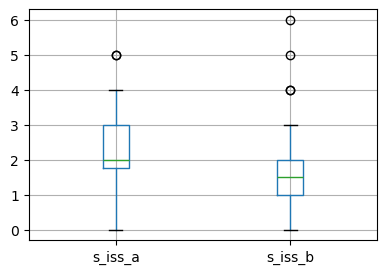

In [105]:
total_solvability_boxplot_tasks = data_df.boxplot(column=['s_iss_a', 's_iss_b'], figsize=(4.5, 3))

In [106]:
wilc_iss_a_vs_b = wilcoxon(
    data_df['s_iss_a'], 
    data_df['s_iss_b'],
    alternative='greater'
)
wilc_iss_a_vs_b.statistic, wilc_iss_a_vs_b.pvalue

(186.0, 0.06887389294090047)

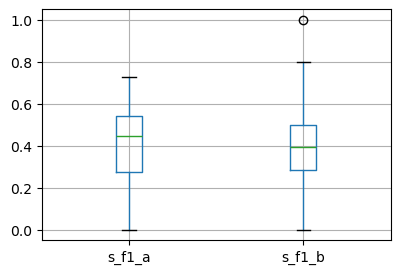

In [107]:
f1_solvability_boxplot_tasks = data_df.boxplot(column=['s_f1_a', 's_f1_b'], figsize=(4.5, 3))

In [108]:
wilc_f1_a_vs_b = wilcoxon(
    data_df['s_f1_a'], 
    data_df['s_f1_b'],
    alternative='two-sided'
)
wilc_f1_a_vs_b.statistic, wilc_f1_a_vs_b.pvalue

(114.5, 0.30990274795652073)

## 2. Issues In Time

In [109]:
timeseries_data_df = pd.read_csv('../ma-eval/time_series/all.csv')
timeseries_data_df

,p_id,group,task,map,timestamp,tag,note,timedelta
0,PA40344,AP,solvability_pixie,LA_3,01:27:30,STA,NaN,0
1,PA40344,AP,solvability_pixie,LA_3,01:27:44,OBS,pathfinding start-room after boss,14
2,PA40344,AP,solvability_pixie,LA_3,01:28:08,vb,ath blocked to boss,38
3,PA40344,AP,solvability_pixie,LA_3,01:28:45,OBS,successive pathfinding,75
4,PA40344,AP,solvability_pixie,LA_3,01:28:56,vb,oftlock 14,86
...,...,...,...,...,...,...,...,...
819,PA38184,AP,pacing_miro,LA_2,14:43:59,Q2A,R A takes longer than B,162
820,PA38184,AP,pacing_miro,LA_2,14:44:08,Q4A,R room 15,171
821,PA38184,AP,pacing_miro,LA_2,14:45:09,Q3A,"W no, B has more enemies than C",232
822,PA38184,AP,pacing_miro,LA_2,14:46:07,Q5A,? 21-2 to 21-3,290


In [110]:
issues_data_df = timeseries_data_df[timeseries_data_df['tag'] == 'ISS']
issues_data_df

,p_id,group,task,map,timestamp,tag,note,timedelta
32,MA7125,AM,solvability_pixie,LA_4,11:33:16,ISS,TP 12 not reachable,138
35,MA7125,AM,solvability_pixie,LA_4,11:36:42,ISS,TP one-directional path 12-11,344
39,MA7125,AM,solvability_miro,LA_3,11:27:20,ISS,cannot got further than marked path (evl: incl...,231
40,MA7125,AM,solvability_miro,LA_3,11:27:49,ISS,TP one-directional path 12-15,260
69,MA26593,AM,solvability_miro,LA_3,11:23:57,ISS,TP softlock in 4 if ability check not passed,99
...,...,...,...,...,...,...,...,...
771,MB67500,BM,solvability_miro,LA_4,15:25:05,ISS,FP 16-37 blocked bc no bombs,164
772,MB67500,BM,solvability_miro,LA_4,15:25:46,ISS,TP can't get to area 28 bc one-directional edge,205
797,PA38184,AP,solvability_pixie,LA_3,14:26:16,ISS,TP need 6 bombs for 22-23 but only get one on ...,270
802,PA38184,AP,solvability_miro,LA_4,14:29:18,ISS,TP can't unlock edge 6 - 12,92


In [111]:
first_issues_df = issues_data_df.loc[issues_data_df.groupby(['p_id', 'task']).timedelta.idxmin()]
first_issues_df

,p_id,group,task,map,timestamp,tag,note,timedelta
629,MA12534,AM,solvability_miro,LA_3,11:21:21,ISS,"TP hard lock 6, pretty confident",159
69,MA26593,AM,solvability_miro,LA_3,11:23:57,ISS,TP softlock in 4 if ability check not passed,99
452,MA34230,AM,solvability_miro,LA_3,17:26:49,ISS,TP if bomb used on 13 - 14: softlock in 14,130
446,MA34230,AM,solvability_pixie,LA_4,17:36:46,ISS,TP 6-12 not unlockable,270
39,MA7125,AM,solvability_miro,LA_3,11:27:20,ISS,cannot got further than marked path (evl: incl...,231
32,MA7125,AM,solvability_pixie,LA_4,11:33:16,ISS,TP 12 not reachable,138
373,MA95137,AM,solvability_miro,LA_3,15:26:14,ISS,TP hardlocked in 6,39
694,MA95935,AM,solvability_miro,LA_3,16:26:50,ISS,TP not enough bombs 22-23,156
314,MB10509,BM,solvability_miro,LA_4,13:28:03,ISS,TP can not get from 6 to 12/hard lock,140
304,MB10509,BM,solvability_pixie,LA_3,13:34:03,ISS,TP hardlock in 6,40


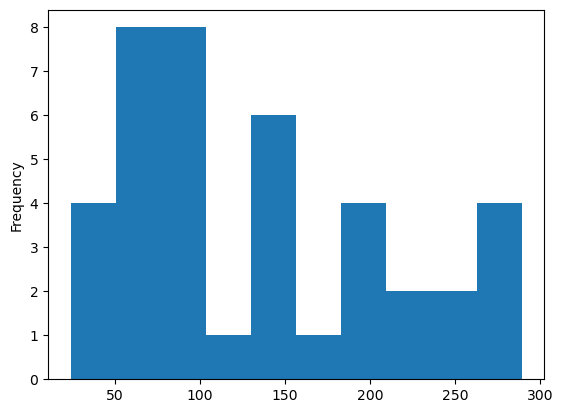

In [ ]:

time_to_first_issue_hist = first_issues_df['timedelta'].plot.hist(by='task')
# time_to_first_issue_hist = first_issues_df.timedelta.plot.hist(groupby='task')
# time_to_first_issue_hist = first_issues_df.plot.hist('timadelta', by='task')

##### Distribution of First Issue Found Events Across Participants By Task

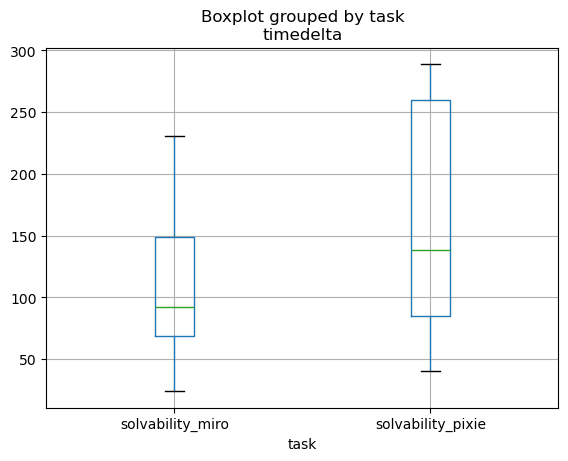

In [113]:
time_to_first_issue_box = first_issues_df.boxplot(by='task', column='timedelta')

##### Time To First Issue By Tool And Map

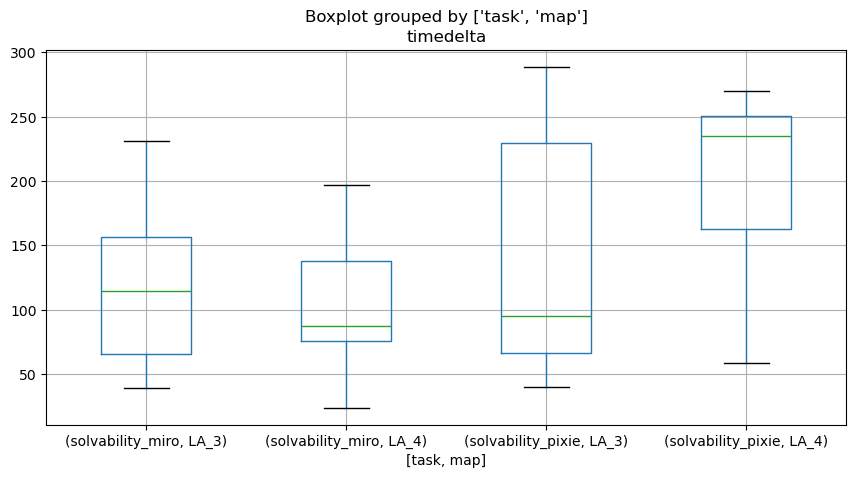

In [114]:
time_to_first_issue_box_task = first_issues_df.boxplot(by=['task', 'map'], column='timedelta', figsize=(10, 5))

##### Distribution of Issue Found Events Across Time

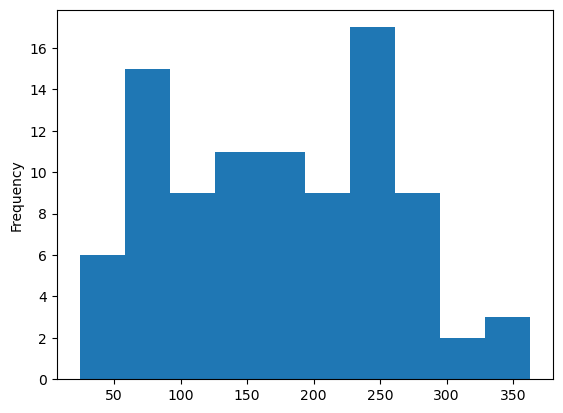

In [115]:
ax2 = issues_data_df['timedelta'].plot.hist()